# Multi-Asset Carry + Tail Hedge

Extends the Spitznagel carry+puts structure beyond AUD/JPY to a diversified basket of carry trades.

**FX carry pairs (all vs JPY):**
- AUD/JPY — classic EM-proxy carry (RBA 0.1-4.5%)
- GBP/JPY — G10 high-yield carry (BOE 0.1-5.25%)
- CAD/JPY — commodity-linked carry (BOC 0.25-5%)
- EUR/JPY — core European carry (ECB 0-4.5%)
- CHF/JPY — negative-rate curiosity (SNB -0.75 to 1.75%)
- MXN/JPY — high-yield EM carry (Banxico 4-11%)
- NZD/JPY — Oceania carry (RBNZ 0.25-5.5%)

**Hedge structure:** For each pair, buy monthly OTM puts (8% OTM) on the high-yielder's futures contract. Budget: 0.5% of notional per month.

**Data:** Real CME futures and options from Databento (2010-2026)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../data/databento'
MONTH_CODES = {'F':1,'G':2,'H':3,'J':4,'K':5,'M':6,
               'N':7,'Q':8,'U':9,'V':10,'X':11,'Z':12}

## 1. Data Loading — Front-Month Futures for All Pairs

In [2]:
def load_front_month(filename):
    """Load futures data and build roll-adjusted front-month series."""
    fut = pd.read_parquet(f'{DATA_DIR}/{filename}')
    outrights = fut[~fut['symbol'].str.contains('-', na=False)].copy()
    outrights = outrights.sort_index()

    # Per-contract price history for roll adjustment
    contract_prices = {}
    for _, row in outrights.iterrows():
        sym = row['symbol']
        date = row.name.normalize().tz_localize(None)
        if sym not in contract_prices:
            contract_prices[sym] = {}
        contract_prices[sym][date] = row['close']

    # Identify front-month (highest volume) per day
    daily_front = {}
    for date, group in outrights.groupby(outrights.index.date):
        best = group.sort_values('volume', ascending=False).iloc[0]
        daily_front[pd.Timestamp(date)] = {
            'symbol': best['symbol'],
            'close': best['close'],
            'volume': best['volume'],
        }

    # Build roll-adjusted return series
    dates = sorted(daily_front.keys())
    records = []
    prev_date = None
    prev_symbol = None

    for date in dates:
        info = daily_front[date]
        cur_symbol = info['symbol']

        if prev_date is None:
            records.append({'date': date, 'close': info['close'], 'return': 0.0})
            prev_date = date
            prev_symbol = cur_symbol
            continue

        if cur_symbol == prev_symbol:
            prev_price = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            cur_price = contract_prices.get(cur_symbol, {}).get(date, 0)
            ret = cur_price / prev_price - 1 if prev_price > 0 else 0.0
        else:
            old_prev = contract_prices.get(prev_symbol, {}).get(prev_date, 0)
            old_cur = contract_prices.get(prev_symbol, {}).get(date, 0)
            ret = old_cur / old_prev - 1 if old_prev > 0 and old_cur > 0 else 0.0

        records.append({'date': date, 'close': info['close'], 'return': ret})
        prev_date = date
        prev_symbol = cur_symbol

    return pd.DataFrame(records).set_index('date')


# Load all FX futures
fx_futures = {}
pairs = {
    'AUD': '6A_FUT_ohlcv1d.parquet',
    'GBP': '6B_FUT_ohlcv1d.parquet',
    'CAD': '6C_FUT_ohlcv1d.parquet',
    'EUR': '6E_FUT_ohlcv1d.parquet',
    'CHF': '6S_FUT_ohlcv1d.parquet',
    'MXN': '6M_FUT_ohlcv1d.parquet',
    'NZD': '6N_FUT_ohlcv1d.parquet',
    'JPY': '6J_FUT_ohlcv1d.parquet',
}

for ccy, filename in pairs.items():
    print(f'Loading {ccy} futures...')
    fx_futures[ccy] = load_front_month(filename)
    f = fx_futures[ccy]
    print(f'  {len(f)} days, {f.index.min().date()} to {f.index.max().date()}, '
          f'close: {f["close"].iloc[-1]:.6f}')

Loading AUD futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 0.711500
Loading GBP futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 1.348300
Loading CAD futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 0.733500
Loading EUR futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 1.182350
Loading CHF futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 1.301650
Loading MXN futures...


  4877 days, 2010-06-06 to 2026-02-27, close: 0.057990
Loading NZD futures...


  4879 days, 2010-06-06 to 2026-02-27, close: 0.600050
Loading JPY futures...


  4880 days, 2010-06-06 to 2026-02-27, close: 0.006417


In [3]:
# Build cross rates vs JPY for each high-yielder
# Cross = CCY/USD futures price / JPY/USD futures price = JPY per unit of CCY
jpy = fx_futures['JPY']

cross_rates = {}
for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN', 'NZD']:
    f = fx_futures[ccy]
    common = f.index.intersection(jpy.index)
    cross = pd.DataFrame({
        f'{ccy.lower()}_jpy': f.loc[common, 'close'] / jpy.loc[common, 'close'],
        'ccy_ret': f.loc[common, 'return'],
        'jpy_ret': jpy.loc[common, 'return'],
        'cross_ret': f.loc[common, 'return'] - jpy.loc[common, 'return'],
    }, index=common)
    cross_rates[ccy] = cross
    
    spot_col = f'{ccy.lower()}_jpy'
    years = (cross.index[-1] - cross.index[0]).days / 365.25
    total = cross[spot_col].iloc[-1] / cross[spot_col].iloc[0]
    cagr = total**(1/years) - 1
    print(f'{ccy}/JPY: {len(cross)} days, range {cross[spot_col].min():.2f}-{cross[spot_col].max():.2f}, '
          f'current {cross[spot_col].iloc[-1]:.2f}, spot CAGR {cagr*100:.2f}%')

AUD/JPY: 4880 days, range 62.48-111.04, current 110.88, spot CAGR 2.53%
GBP/JPY: 4880 days, range 117.11-213.44, current 210.11, spot CAGR 2.99%
CAD/JPY: 4880 days, range 72.47-117.73, current 114.31, spot CAGR 1.82%
EUR/JPY: 4880 days, range 94.22-185.94, current 184.25, spot CAGR 3.38%
CHF/JPY: 4880 days, range 78.51-203.71, current 202.84, spot CAGR 6.20%
MXN/JPY: 4877 days, range 4.24-9.37, current 9.04, spot CAGR 1.65%
NZD/JPY: 4879 days, range 56.74-97.85, current 93.51, spot CAGR 2.73%


## 2. Carry Rate Series

For each pair, carry = high-yield rate - JPY rate. The BOJ kept rates at 0% until mid-2024, making JPY the universal funding currency.

In [4]:
# Historical policy rates (annual averages, %)
# Sources: central bank websites, FRED

boj_rates = {y: 0.0 for y in range(2010, 2027)}
boj_rates[2024] = 0.25
boj_rates[2025] = 0.50
boj_rates[2026] = 0.50

policy_rates = {
    'AUD': {  # RBA cash rate
        2010: 4.25, 2011: 4.50, 2012: 3.50, 2013: 2.75, 2014: 2.50,
        2015: 2.00, 2016: 1.75, 2017: 1.50, 2018: 1.50, 2019: 1.00,
        2020: 0.25, 2021: 0.10, 2022: 1.85, 2023: 4.10, 2024: 4.35,
        2025: 4.35, 2026: 4.10,
    },
    'GBP': {  # BOE bank rate
        2010: 0.50, 2011: 0.50, 2012: 0.50, 2013: 0.50, 2014: 0.50,
        2015: 0.50, 2016: 0.25, 2017: 0.35, 2018: 0.65, 2019: 0.75,
        2020: 0.25, 2021: 0.15, 2022: 2.00, 2023: 4.75, 2024: 5.00,
        2025: 4.50, 2026: 4.25,
    },
    'CAD': {  # BOC overnight rate
        2010: 0.50, 2011: 1.00, 2012: 1.00, 2013: 1.00, 2014: 1.00,
        2015: 0.75, 2016: 0.50, 2017: 0.75, 2018: 1.50, 2019: 1.75,
        2020: 0.50, 2021: 0.25, 2022: 2.50, 2023: 4.75, 2024: 4.50,
        2025: 3.25, 2026: 3.00,
    },
    'EUR': {  # ECB main refinancing rate
        2010: 1.00, 2011: 1.25, 2012: 0.75, 2013: 0.50, 2014: 0.15,
        2015: 0.05, 2016: 0.00, 2017: 0.00, 2018: 0.00, 2019: 0.00,
        2020: 0.00, 2021: 0.00, 2022: 1.25, 2023: 4.00, 2024: 4.25,
        2025: 3.15, 2026: 2.65,
    },
    'CHF': {  # SNB policy rate
        2010: 0.25, 2011: 0.00, 2012: 0.00, 2013: 0.00, 2014: 0.00,
        2015: -0.75, 2016: -0.75, 2017: -0.75, 2018: -0.75, 2019: -0.75,
        2020: -0.75, 2021: -0.75, 2022: 0.25, 2023: 1.50, 2024: 1.50,
        2025: 0.50, 2026: 0.25,
    },
    'MXN': {  # Banxico overnight rate
        2010: 4.50, 2011: 4.50, 2012: 4.50, 2013: 4.00, 2014: 3.50,
        2015: 3.25, 2016: 5.00, 2017: 7.00, 2018: 8.00, 2019: 8.00,
        2020: 5.00, 2021: 4.50, 2022: 8.50, 2023: 11.25, 2024: 10.75,
        2025: 9.50, 2026: 8.50,
    },
    'NZD': {  # RBNZ official cash rate
        2010: 3.00, 2011: 2.50, 2012: 2.50, 2013: 2.50, 2014: 3.25,
        2015: 2.75, 2016: 2.00, 2017: 1.75, 2018: 1.75, 2019: 1.25,
        2020: 0.50, 2021: 0.50, 2022: 2.75, 2023: 5.50, 2024: 5.50,
        2025: 4.25, 2026: 3.50,
    },
}

# Attach daily carry to each cross rate DataFrame
for ccy in cross_rates:
    cr = cross_rates[ccy]
    cr['ccy_rate'] = cr.index.year.map(lambda y: policy_rates[ccy].get(y, 0)) / 100
    cr['jpn_rate'] = cr.index.year.map(lambda y: boj_rates.get(y, 0)) / 100
    cr['daily_carry'] = (cr['ccy_rate'] - cr['jpn_rate']) / 365

# Summary
print(f'{"Pair":>10} {"Avg carry":>10} {"2010":>7} {"2015":>7} {"2020":>7} {"2023":>7} {"2025":>7}')
print('-' * 60)
for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN', 'NZD']:
    cr = cross_rates[ccy]
    avg = cr['daily_carry'].mean() * 365 * 100
    row = f'{ccy}/JPY:  {avg:>8.2f}%'
    for yr in [2010, 2015, 2020, 2023, 2025]:
        diff = policy_rates[ccy].get(yr, 0) - boj_rates.get(yr, 0)
        row += f' {diff:>6.2f}%'
    print(row)

      Pair  Avg carry    2010    2015    2020    2023    2025
------------------------------------------------------------
AUD/JPY:      2.43%   4.25%   2.00%   0.25%   4.10%   3.85%
GBP/JPY:      1.36%   0.50%   0.50%   0.25%   4.75%   4.00%
CAD/JPY:      1.59%   0.50%   0.75%   0.50%   4.75%   2.75%
EUR/JPY:      0.99%   1.00%   0.05%   0.00%   4.00%   2.65%
CHF/JPY:     -0.14%   0.25%  -0.75%  -0.75%   1.50%   0.00%
MXN/JPY:      6.39%   4.50%   3.25%   5.00%  11.25%   9.00%
NZD/JPY:      2.59%   3.00%   2.75%   0.50%   5.50%   3.75%


## 3. Option Loading and Selection

For each carry pair, we buy monthly OTM puts on the high-yielder's futures contract to hedge against a crash in that currency vs JPY.

In [5]:
# Strike divisors for each product
# All standard CME FX options use /1000 except JPY (/100000) and MXN (/10000)
STRIKE_DIVISORS = {
    'AUD': 1000, 'GBP': 1000, 'CAD': 1000, 'EUR': 1000,
    'CHF': 1000, 'NZD': 1000, 'MXN': 10000, 'JPY': 100000,
}

# Option file configurations: (old_file, new_file, old_prefix, new_prefix, cutoff)
OPT_CONFIGS = {
    'AUD': ('6A_OPT_ohlcv1d.parquet', 'ADU_OPT_ohlcv1d.parquet',
            ['6A'], ['ADU'], '2016-08-23'),
    'GBP': ('6B_OPT_ohlcv1d.parquet', 'GBU_OPT_ohlcv1d.parquet',
            ['6B'], ['GBU'], '2016-08-23'),
    'CAD': ('6C_OPT_ohlcv1d.parquet', 'CAU_OPT_ohlcv1d.parquet',
            ['6C'], ['CAU'], '2016-08-22'),
    'EUR': ('6E_OPT_ohlcv1d.parquet', 'EUU_OPT_ohlcv1d.parquet',
            ['6E'], ['EUU'], '2016-08-09'),
    'CHF': ('6S_OPT_ohlcv1d.parquet', None,
            ['6S'], None, None),  # CHF only has old-format options to 2017
    'MXN': ('6M_OPT_ohlcv1d.parquet', None,
            ['6M'], None, None),  # MXN only has 6M options
    'NZD': ('6N_OPT_ohlcv1d.parquet', None,
            ['6N'], None, None),  # NZD: very sparse options
}


def parse_option_generic(sym, date_year, prefixes, strike_div):
    """Parse CME FX option symbol -> (month, year, opt_type, strike).
    
    Handles both old format (6XY0 C1234) and new format (XXXYZ C1234).
    """
    parts = sym.split()
    if len(parts) != 2:
        return None
    contract, opt = parts
    opt_type = opt[0]
    if opt_type not in ('C', 'P'):
        return None
    try:
        strike_raw = int(opt[1:])
    except ValueError:
        return None
    
    strike = strike_raw / strike_div
    
    # Find matching prefix and extract month/year codes
    month_code = None
    year_digit = None
    for pfx in prefixes:
        if contract.startswith(pfx):
            rest = contract[len(pfx):]
            if len(rest) >= 2:
                month_code = rest[0]
                try:
                    year_digit = int(rest[1])
                except ValueError:
                    continue
                break
    
    if month_code is None or year_digit is None:
        return None
    
    month = MONTH_CODES.get(month_code, 0)
    if month == 0:
        return None
    
    decade_base = (date_year // 10) * 10
    year = decade_base + year_digit
    if year < date_year - 2:
        year += 10
    
    return month, year, opt_type, strike


def load_fx_options_generic(ccy):
    """Load FX options for a given currency, merging old + new format files."""
    config = OPT_CONFIGS[ccy]
    old_file, new_file, old_prefixes, new_prefixes, cutoff = config
    strike_div = STRIKE_DIVISORS[ccy]
    
    # Load old-format options
    old = pd.read_parquet(f'{DATA_DIR}/{old_file}')
    old = old[~old['symbol'].str.contains('UD:', na=False)].copy()
    
    if new_file is not None:
        new = pd.read_parquet(f'{DATA_DIR}/{new_file}')
        new = new[~new['symbol'].str.contains('UD:', na=False)].copy()
        cutoff_ts = pd.Timestamp(cutoff, tz='UTC')
        old = old[old.index < cutoff_ts]
        combined = pd.concat([old, new]).sort_index()
        all_prefixes = old_prefixes + new_prefixes
    else:
        combined = old.sort_index()
        all_prefixes = old_prefixes
    
    records = []
    for idx, row in combined.iterrows():
        parsed = parse_option_generic(row['symbol'], idx.year, all_prefixes, strike_div)
        if parsed is None:
            continue
        month, year, opt_type, strike = parsed
        try:
            first_of_month = pd.Timestamp(year=year, month=month, day=1)
        except ValueError:
            continue
        third_wed = first_of_month + pd.offsets.WeekOfMonth(week=2, weekday=2)
        expiry = (third_wed - pd.offsets.BDay(2)).tz_localize('UTC')
        records.append({
            'date': idx, 'symbol': row['symbol'], 'opt_type': opt_type,
            'strike': strike, 'expiry': expiry,
            'close': row['close'], 'volume': row['volume'],
        })
    
    return pd.DataFrame(records)


# Load options for all pairs with sufficient data
fx_options = {}
# Focus on pairs with deep option markets: AUD, GBP, CAD, EUR
# CHF: only to mid-2017. MXN: sparse. NZD: very sparse.
for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    print(f'Loading {ccy} options...')
    opts = load_fx_options_generic(ccy)
    fx_options[ccy] = opts
    puts = (opts['opt_type'] == 'P').sum()
    calls = (opts['opt_type'] == 'C').sum()
    print(f'  {len(opts):,} total (puts: {puts:,}, calls: {calls:,}), '
          f'{opts["date"].min().date()} to {opts["date"].max().date()}')

Loading AUD options...


  281,447 total (puts: 150,657, calls: 130,790), 2010-06-06 to 2026-02-27
Loading GBP options...


  291,950 total (puts: 151,965, calls: 139,985), 2010-06-06 to 2026-02-27
Loading CAD options...


  209,251 total (puts: 110,536, calls: 98,715), 2010-06-06 to 2026-02-27
Loading EUR options...


  612,216 total (puts: 317,901, calls: 294,315), 2010-06-06 to 2026-02-27
Loading CHF options...


  47,067 total (puts: 22,974, calls: 24,093), 2010-06-07 to 2017-06-09
Loading MXN options...
  7,576 total (puts: 3,955, calls: 3,621), 2013-01-22 to 2026-02-27


In [6]:
def select_monthly_options(opts, front_prices, opt_type='P', otm_target=0.92):
    """Select one OTM option per month.
    
    For puts: moneyness = strike/underlying < 1 (OTM when below spot)
    For calls: moneyness = strike/underlying > 1 (OTM when above spot)
    
    otm_target for puts: 0.92 = 8% below spot
    otm_target for calls: 1.08 = 8% above spot
    """
    filtered = opts[opts['opt_type'] == opt_type].copy()
    if len(filtered) == 0:
        return pd.DataFrame()

    prices = front_prices[['close']].rename(columns={'close': 'fut_close'})
    prices.index = prices.index.tz_localize('UTC')
    filtered['date_norm'] = filtered['date'].dt.normalize()
    filtered = filtered.merge(prices, left_on='date_norm', right_index=True, how='left')
    filtered = filtered.dropna(subset=['fut_close'])
    filtered['moneyness'] = filtered['strike'] / filtered['fut_close']
    filtered['year_month'] = filtered['date'].dt.to_period('M')

    selections = []
    for ym, group in filtered.groupby('year_month'):
        first_day = group['date'].min()
        day_opts = group[group['date'] == first_day]
        if len(day_opts) == 0:
            continue

        # Nearest expiry > 14 days out
        day_opts = day_opts[day_opts['expiry'] > first_day + pd.Timedelta(days=14)]
        if len(day_opts) == 0:
            continue
        nearest_exp = day_opts['expiry'].min()
        day_opts = day_opts[day_opts['expiry'] == nearest_exp]

        # Filter OTM only
        if opt_type == 'P':
            day_opts = day_opts[day_opts['moneyness'] < 1.0]
        else:
            day_opts = day_opts[day_opts['moneyness'] > 1.0]

        if len(day_opts) == 0:
            continue

        day_opts = day_opts.copy()
        day_opts['dist'] = (day_opts['moneyness'] - otm_target).abs()
        candidates = day_opts.nsmallest(5, 'dist')
        best = candidates.sort_values('volume', ascending=False).iloc[0]

        if best['close'] <= 0:
            continue

        selections.append({
            'entry_date': first_day,
            'symbol': best['symbol'],
            'strike': best['strike'],
            'entry_price': best['close'],
            'expiry': best['expiry'],
            'underlying': best['fut_close'],
            'moneyness': best['moneyness'],
            'volume': best['volume'],
        })

    return pd.DataFrame(selections)


# Select 8% OTM puts for each pair
put_selections = {}
for ccy in fx_options:
    front = pd.DataFrame({'close': fx_futures[ccy]['close']})
    sels = select_monthly_options(fx_options[ccy], front, opt_type='P', otm_target=0.92)
    put_selections[ccy] = sels
    if len(sels) > 0:
        print(f'{ccy} puts: {len(sels)} months selected, '
              f'{sels["entry_date"].min().date()} to {sels["entry_date"].max().date()}, '
              f'avg moneyness {sels["moneyness"].mean():.3f}')
    else:
        print(f'{ccy} puts: no selections (insufficient option data)')

AUD puts: 182 months selected, 2010-06-07 to 2026-02-01, avg moneyness 0.955
GBP puts: 124 months selected, 2010-06-07 to 2021-02-01, avg moneyness 0.962


CAD puts: 180 months selected, 2010-06-06 to 2025-12-01, avg moneyness 0.974
EUR puts: 185 months selected, 2010-06-06 to 2026-02-01, avg moneyness 0.959


CHF puts: 81 months selected, 2010-06-07 to 2017-06-02, avg moneyness 0.974
MXN puts: 121 months selected, 2013-02-05 to 2026-02-02, avg moneyness 0.968


## 4. Backtest Engine

Run carry + puts for each pair at 1x and 3x leverage:
- **Unhedged**: pure carry + spot
- **Carry + puts**: 0.5% of notional per month on OTM puts

In [7]:
def build_settlement_lookup(opts):
    """Pre-build symbol -> [(date, price)] for fast settlement."""
    lookup = {}
    for _, row in opts.iterrows():
        sym = row['symbol']
        if sym not in lookup:
            lookup[sym] = []
        lookup[sym].append((row['date'], row['close']))
    for sym in lookup:
        lookup[sym].sort(key=lambda x: x[0])
    return lookup


def get_settlement(symbol, strike, expiry, opt_type, lookup, front_prices):
    """Get option settlement price."""
    window_start = expiry - pd.Timedelta(days=5)
    window_end = expiry + pd.Timedelta(days=2)
    if symbol in lookup:
        near = [(d, p) for d, p in lookup[symbol] if window_start <= d <= window_end]
        if near:
            return near[-1][1]
    # Fallback: intrinsic value
    near_dates = front_prices[
        (front_prices.index >= (expiry - pd.Timedelta(days=3)).tz_localize(None)) &
        (front_prices.index <= (expiry + pd.Timedelta(days=3)).tz_localize(None))
    ]
    if len(near_dates) > 0:
        underlying = near_dates.iloc[-1]['close']
        if opt_type == 'P':
            return max(0, strike - underlying)
        else:
            return max(0, underlying - strike)
    return 0.0


def precompute_settlements(selections, opt_type, lookup, front_prices):
    """Pre-compute settlement for all selected options."""
    put_map = {}
    for _, row in selections.iterrows():
        settle = get_settlement(row['symbol'], row['strike'], row['expiry'],
                                opt_type, lookup, front_prices)
        entry_price = row['entry_price']
        pnl_ratio = (settle - entry_price) / entry_price if entry_price > 0 else 0
        put_map[row['entry_date']] = {
            'symbol': row['symbol'],
            'strike': row['strike'],
            'entry_price': entry_price,
            'settlement': settle,
            'pnl_ratio': pnl_ratio,
            'moneyness': row['moneyness'],
        }
    return put_map


def run_carry_backtest(cross_df, front_prices, put_sels, all_opts,
                       leverage=1, put_budget=0.005):
    """Run leveraged carry + puts backtest for a single pair.
    
    Args:
        cross_df: DataFrame with daily_carry, cross_ret columns
        front_prices: DataFrame with close column (for settlement fallback)
        put_sels: DataFrame of selected put options
        all_opts: DataFrame of all options (for settlement lookup)
        leverage: leverage multiplier
        put_budget: fraction of notional for puts per month (0 = unhedged)
    """
    if put_budget > 0 and len(put_sels) > 0:
        lookup = build_settlement_lookup(all_opts)
        put_map = precompute_settlements(put_sels, 'P', lookup, front_prices)
    else:
        put_map = {}

    capital = 100.0
    records = []
    current_month = None

    for date in cross_df.index:
        if capital <= 0:
            records.append({'date': date, 'capital': 0, 'daily_carry': 0,
                            'daily_spot': 0, 'put_pnl': 0})
            continue

        notional = capital * leverage
        carry_income = notional * cross_df.loc[date, 'daily_carry']
        spot_pnl = notional * cross_df.loc[date, 'cross_ret']

        put_pnl = 0
        ym = pd.Timestamp(date).to_period('M')
        if ym != current_month:
            current_month = ym
            date_tz = pd.Timestamp(date, tz='UTC')
            if put_budget > 0 and date_tz in put_map:
                cost = put_budget * notional
                put_pnl = cost * put_map[date_tz]['pnl_ratio']

        capital += carry_income + spot_pnl + put_pnl
        records.append({
            'date': date, 'capital': capital, 'daily_carry': carry_income,
            'daily_spot': spot_pnl, 'put_pnl': put_pnl,
        })

    return pd.DataFrame(records).set_index('date')


# Empty selections placeholder
empty_sels = pd.DataFrame(columns=['entry_date', 'symbol', 'strike', 'entry_price',
                                    'expiry', 'underlying', 'moneyness', 'volume'])

In [8]:
# Run backtests for all pairs
# Pairs with deep option data: AUD, GBP, CAD, EUR
# Pairs with partial option data: CHF (to 2017), MXN (sparse)
# We run hedged only where we have option data; unhedged for all

all_results = {}  # {(ccy, leverage, hedged): backtest_df}

for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    cr = cross_rates[ccy]
    front = pd.DataFrame({'close': fx_futures[ccy]['close']})
    sels = put_selections.get(ccy, empty_sels)
    opts = fx_options.get(ccy, pd.DataFrame())
    has_hedge = len(sels) >= 12  # at least 1 year of option data
    
    for lev in [1, 3]:
        # Unhedged
        print(f'Running {ccy}/JPY {lev}x unhedged...')
        all_results[(ccy, lev, False)] = run_carry_backtest(
            cr, front, empty_sels, opts, leverage=lev, put_budget=0
        )
        
        # Hedged (only if sufficient option data)
        if has_hedge:
            print(f'Running {ccy}/JPY {lev}x hedged...')
            all_results[(ccy, lev, True)] = run_carry_backtest(
                cr, front, sels, opts, leverage=lev, put_budget=0.005
            )

print('\nDone!')

Running AUD/JPY 1x unhedged...
Running AUD/JPY 1x hedged...


Running AUD/JPY 3x unhedged...
Running AUD/JPY 3x hedged...


Running GBP/JPY 1x unhedged...
Running GBP/JPY 1x hedged...


Running GBP/JPY 3x unhedged...
Running GBP/JPY 3x hedged...


Running CAD/JPY 1x unhedged...
Running CAD/JPY 1x hedged...


...

Running EUR/JPY 3x unhedged...
Running EUR/JPY 3x hedged...


Running CHF/JPY 1x unhedged...
Running CHF/JPY 1x hedged...


Running CHF/JPY 3x unhedged...
Running CHF/JPY 3x hedged...


Running MXN/JPY 1x unhedged...
Running MXN/JPY 1x hedged...
Running MXN/JPY 3x unhedged...


Running MXN/JPY 3x hedged...

Done!


## 5. Results Summary Table

In [9]:
def compute_stats(capital_series):
    """Compute comprehensive strategy stats from capital series."""
    cap = capital_series[capital_series > 0]
    if len(cap) < 252:
        return None
    daily_ret = cap.pct_change().dropna()
    years = (cap.index[-1] - cap.index[0]).days / 365.25
    total_ret = cap.iloc[-1] / cap.iloc[0]
    ann_ret = total_ret ** (1/years) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    max_dd = (cap / cap.cummax() - 1).min()

    downside = daily_ret[daily_ret < 0]
    downside_std = downside.std() * np.sqrt(252) if len(downside) > 1 else ann_vol
    sortino = ann_ret / downside_std if downside_std > 0 else 0

    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0

    skew = daily_ret.skew()
    kurt = daily_ret.kurtosis()

    # Max drawdown duration
    drawdown = cap / cap.cummax() - 1
    in_dd = drawdown < 0
    dd_groups = (~in_dd).cumsum()
    if in_dd.any():
        dd_durations = in_dd.groupby(dd_groups).sum()
        max_dd_days = int(dd_durations.max())
    else:
        max_dd_days = 0

    # Yearly returns for win rate
    yearly_ret = cap.resample('YE').last().pct_change().dropna()
    pct_positive_years = (yearly_ret > 0).mean() * 100

    return {
        'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
        'sortino': sortino, 'calmar': calmar,
        'max_dd': max_dd, 'max_dd_days': max_dd_days,
        'skew': skew, 'kurt': kurt,
        'pct_pos_years': pct_positive_years,
        'total': total_ret,
    }


# ========= 1x Leverage =========
print('=' * 130)
print('MULTI-ASSET FX CARRY vs JPY — 1x LEVERAGE')
print('=' * 130)
print(f'{"Pair":>12} {"Type":>10} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"DD days":>7} {"Skew":>6} {"Kurt":>6} {"Win%":>5} {"Total":>7}')
print('-' * 130)

for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    for hedged in [False, True]:
        key = (ccy, 1, hedged)
        if key not in all_results:
            continue
        s = compute_stats(all_results[key]['capital'])
        if s is None:
            continue
        label = f'{ccy}/JPY'
        htype = 'hedged' if hedged else 'unhedged'
        print(f'{label:>12} {htype:>10} {s["ann_ret"]*100:>7.2f}% {s["ann_vol"]*100:>5.1f}% '
              f'{s["sharpe"]:>7.3f} {s["sortino"]:>8.3f} {s["calmar"]:>7.3f} '
              f'{s["max_dd"]*100:>6.1f}% {s["max_dd_days"]:>7d} '
              f'{s["skew"]:>6.2f} {s["kurt"]:>6.1f} {s["pct_pos_years"]:>4.0f}% '
              f'{s["total"]:>6.1f}x')
    print()

# ========= 3x Leverage =========
print()
print('=' * 130)
print('MULTI-ASSET FX CARRY vs JPY — 3x LEVERAGE')
print('=' * 130)
print(f'{"Pair":>12} {"Type":>10} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"Calmar":>7} {"MaxDD":>7} {"DD days":>7} {"Skew":>6} {"Kurt":>6} {"Win%":>5} {"Total":>7}')
print('-' * 130)

for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    for hedged in [False, True]:
        key = (ccy, 3, hedged)
        if key not in all_results:
            continue
        s = compute_stats(all_results[key]['capital'])
        if s is None:
            continue
        label = f'{ccy}/JPY'
        htype = 'hedged' if hedged else 'unhedged'
        print(f'{label:>12} {htype:>10} {s["ann_ret"]*100:>7.2f}% {s["ann_vol"]*100:>5.1f}% '
              f'{s["sharpe"]:>7.3f} {s["sortino"]:>8.3f} {s["calmar"]:>7.3f} '
              f'{s["max_dd"]*100:>6.1f}% {s["max_dd_days"]:>7d} '
              f'{s["skew"]:>6.2f} {s["kurt"]:>6.1f} {s["pct_pos_years"]:>4.0f}% '
              f'{s["total"]:>6.1f}x')
    print()

MULTI-ASSET FX CARRY vs JPY — 1x LEVERAGE
        Pair       Type     CAGR    Vol  Sharpe  Sortino  Calmar   MaxDD DD days   Skew   Kurt  Win%   Total
----------------------------------------------------------------------------------------------------------------------------------
     AUD/JPY   unhedged    6.85%  11.1%   0.619    0.844   0.244  -28.1%    2273  -0.25    3.2   75%    2.8x
     AUD/JPY     hedged   14.08%  19.0%   0.743    1.715   0.621  -22.7%    1096  21.21  786.2   94%    7.9x

     GBP/JPY   unhedged    5.04%   9.9%   0.508    0.675   0.142  -35.4%    2480  -0.57   12.1   69%    2.2x
     GBP/JPY     hedged    8.38%  12.4%   0.676    1.112   0.237  -35.3%    1824   5.75  118.8   88%    3.5x

     CAD/JPY   unhedged    4.25%  10.0%   0.427    0.596   0.155  -27.5%    2266  -0.15    3.0   75%    1.9x
     CAD/JPY     hedged    7.22%  12.0%   0.604    0.999   0.289  -25.0%    1988   4.88   99.7   88%    3.0x

     EUR/JPY   unhedged    4.20%   9.2%   0.457    0.628   0.

## 6. Year-by-Year Returns

In [10]:
# Year-by-year returns at 1x leverage, unhedged vs hedged
for lev in [1, 3]:
    print('=' * 140)
    print(f'YEAR-BY-YEAR RETURNS — {lev}x LEVERAGE (unhedged / hedged)')
    print('=' * 140)
    
    # Collect yearly returns
    yearly_data = {}
    cols = []
    for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
        for hedged in [False, True]:
            key = (ccy, lev, hedged)
            if key not in all_results:
                continue
            cap = all_results[key]['capital']
            cap = cap[cap > 0]
            yearly = cap.resample('YE').last().pct_change().dropna()
            tag = f'{ccy} {"H" if hedged else "U"}'
            yearly_data[tag] = yearly
            cols.append(tag)
    
    all_years = sorted(set(y.year for ys in yearly_data.values() for y in ys.index))
    
    # Print header
    header = f'{"Year":>6}'
    for c in cols:
        header += f'  {c:>8}'
    print(header)
    print('-' * 140)
    
    for year in all_years:
        row = f'{year:>6}'
        for c in cols:
            ys = yearly_data[c]
            match = ys[ys.index.year == year]
            if len(match) > 0:
                ret = match.iloc[0]
                row += f'  {ret*100:>7.1f}%'
            else:
                row += f'  {"---":>8}'
        print(row)
    
    # Averages
    print('-' * 140)
    row = f'{"Avg":>6}'
    for c in cols:
        avg = yearly_data[c].mean()
        row += f'  {avg*100:>7.1f}%'
    print(row)
    
    row = f'{"%+":>6}'
    for c in cols:
        pct = (yearly_data[c] > 0).mean() * 100
        row += f'  {pct:>7.0f}%'
    print(row)
    print()

YEAR-BY-YEAR RETURNS — 1x LEVERAGE (unhedged / hedged)
  Year     AUD U     AUD H     GBP U     GBP H     CAD U     CAD H     EUR U     EUR H     CHF U     CHF H     MXN U     MXN H
--------------------------------------------------------------------------------------------------------------------------------------------
  2011     -1.2%     52.6%     -6.9%      3.1%     -8.4%      3.0%     -9.1%    -10.4%     -6.6%    101.9%    -12.1%    -12.1%
  2012     21.9%     16.0%     16.8%     12.2%     18.0%     15.3%     15.8%     13.8%     15.5%     13.4%     31.7%     31.7%
  2013      8.9%     71.0%     24.3%     48.2%     14.6%     23.3%     25.7%     18.9%     22.8%     19.0%     24.7%     24.7%
  2014      8.3%     19.2%      6.6%     20.0%      5.0%     37.0%     -1.2%     19.4%      1.7%      3.2%      5.4%      7.1%
  2015     -6.8%    -10.5%     -3.8%      0.2%    -14.1%    -12.0%    -10.1%     15.3%     -2.5%     -5.9%     -9.0%     -5.1%
  2016     -1.2%      1.3%    -19.0%    -2

## 7. Equity Curves

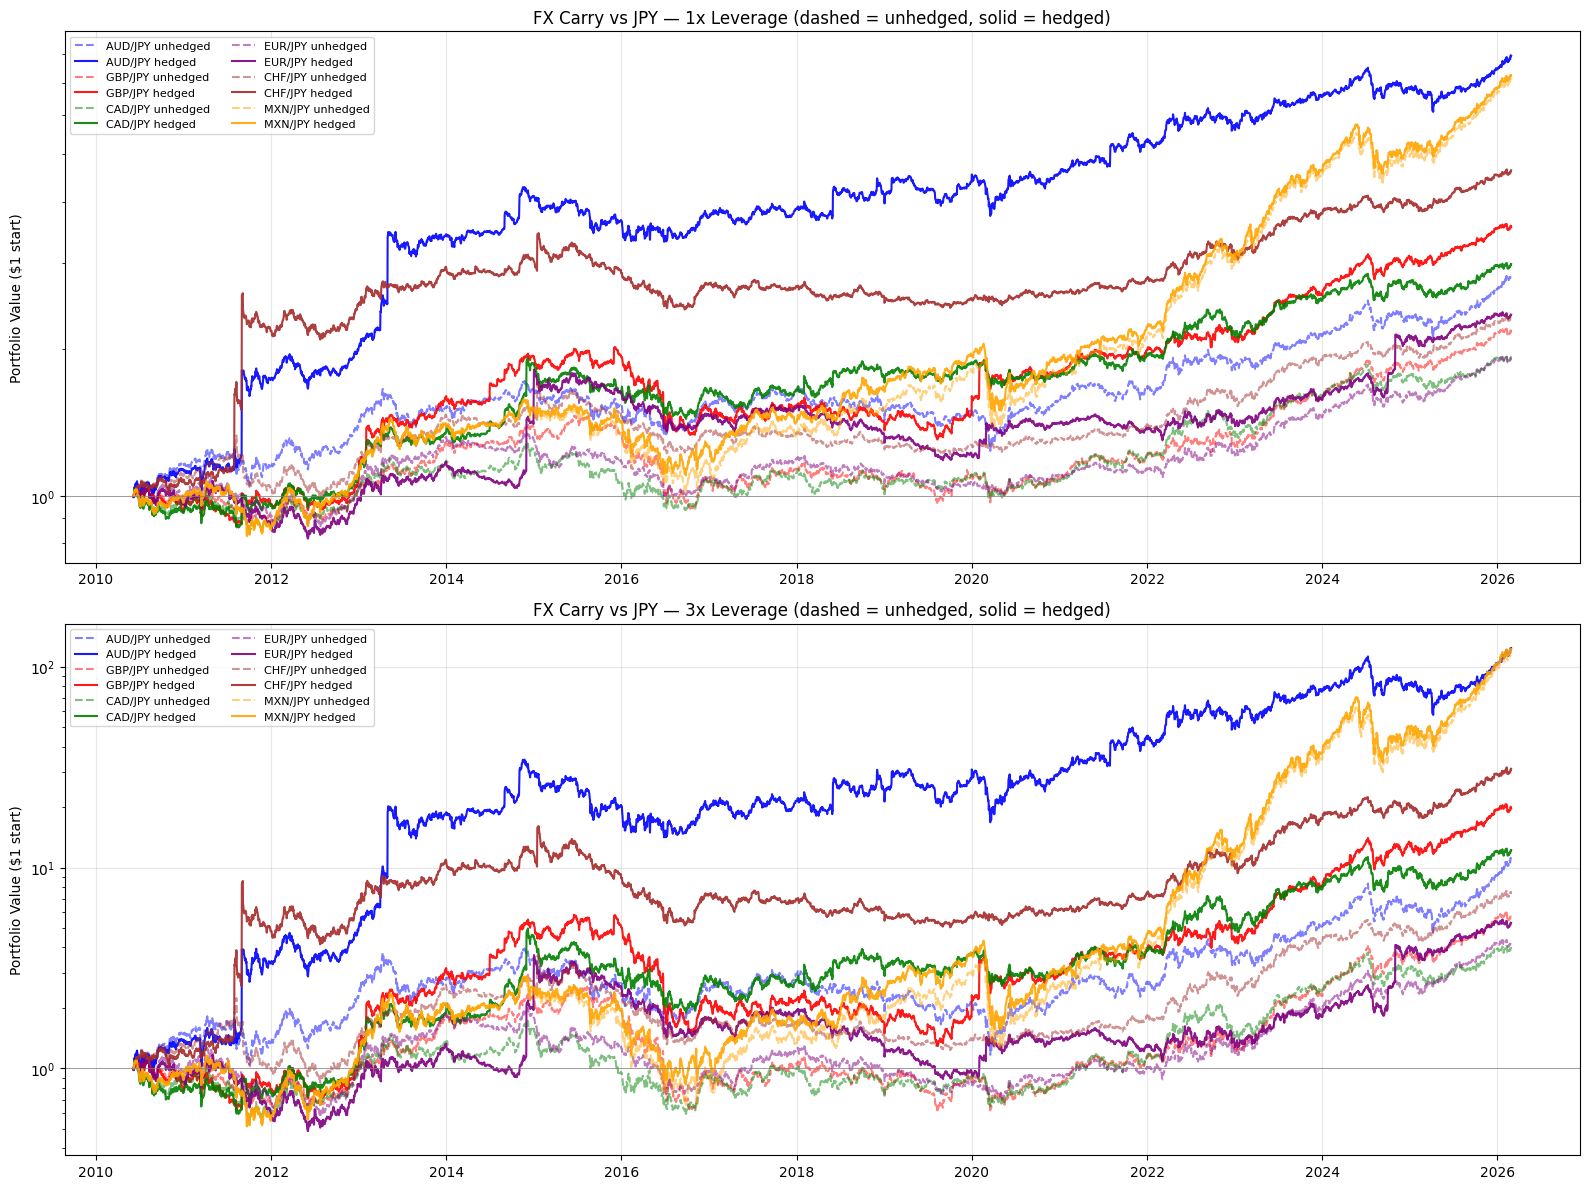

Saved to research/multi_asset_carry_curves.png


In [11]:
# Plot equity curves for all pairs at 1x leverage
colors = {'AUD': 'blue', 'GBP': 'red', 'CAD': 'green',
          'EUR': 'purple', 'CHF': 'brown', 'MXN': 'orange'}

fig, axes = plt.subplots(2, 1, figsize=(16, 12))

# --- 1x unhedged vs hedged ---
ax = axes[0]
for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    key_u = (ccy, 1, False)
    if key_u in all_results:
        cap = all_results[key_u]['capital'] / 100
        ax.plot(cap.index, cap, color=colors[ccy], linestyle='--', alpha=0.5,
                label=f'{ccy}/JPY unhedged')
    key_h = (ccy, 1, True)
    if key_h in all_results:
        cap = all_results[key_h]['capital'] / 100
        ax.plot(cap.index, cap, color=colors[ccy], linestyle='-', alpha=0.9,
                label=f'{ccy}/JPY hedged')

ax.set_title('FX Carry vs JPY — 1x Leverage (dashed = unhedged, solid = hedged)')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(1, color='gray', linewidth=0.5)
ax.set_yscale('log')

# --- 3x unhedged vs hedged ---
ax = axes[1]
for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    key_u = (ccy, 3, False)
    if key_u in all_results:
        cap = all_results[key_u]['capital'] / 100
        ax.plot(cap.index, cap, color=colors[ccy], linestyle='--', alpha=0.5,
                label=f'{ccy}/JPY unhedged')
    key_h = (ccy, 3, True)
    if key_h in all_results:
        cap = all_results[key_h]['capital'] / 100
        ax.plot(cap.index, cap, color=colors[ccy], linestyle='-', alpha=0.9,
                label=f'{ccy}/JPY hedged')

ax.set_title('FX Carry vs JPY — 3x Leverage (dashed = unhedged, solid = hedged)')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
ax.axhline(1, color='gray', linewidth=0.5)
ax.set_yscale('log')

plt.tight_layout()
plt.savefig('../research/multi_asset_carry_curves.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved to research/multi_asset_carry_curves.png')

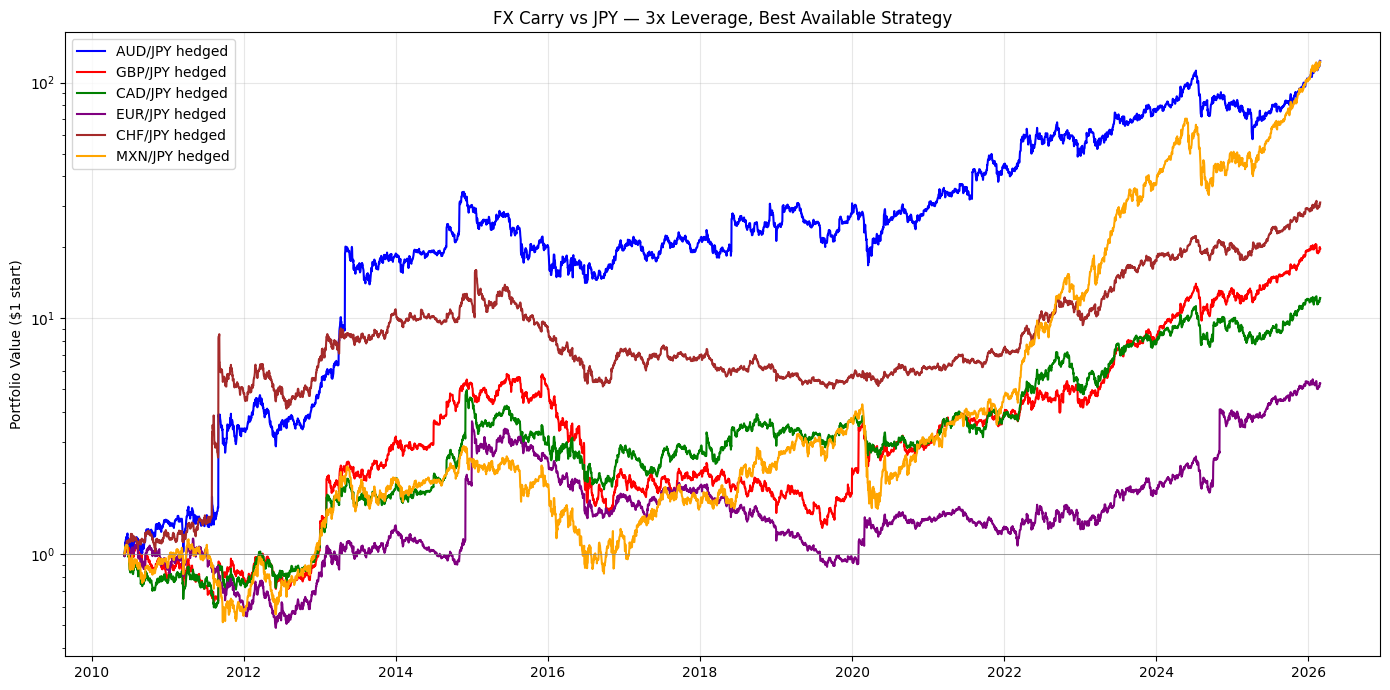

In [12]:
# Focused comparison: hedged strategies only, 3x leverage
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    key = (ccy, 3, True)
    if key not in all_results:
        # Fall back to unhedged if no hedge available
        key = (ccy, 3, False)
    if key in all_results:
        cap = all_results[key]['capital'] / 100
        hedged = key[2]
        label = f'{ccy}/JPY {"hedged" if hedged else "unhedged"}'
        ax.plot(cap.index, cap, color=colors[ccy], linewidth=1.5, label=label)

ax.set_title('FX Carry vs JPY — 3x Leverage, Best Available Strategy')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
ax.axhline(1, color='gray', linewidth=0.5)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 8. Crisis Performance

How did each carry pair perform during major risk-off episodes?

In [13]:
crises = [
    ('2011 EU debt',       '2011-07-01', '2011-10-31'),
    ('2013 taper tantrum', '2013-05-01', '2013-08-31'),
    ('2015 China deval',   '2015-07-01', '2015-09-30'),
    ('2018 trade war',     '2018-01-01', '2018-12-31'),
    ('2020 COVID',         '2020-01-01', '2020-04-30'),
    ('2022 rate hikes',    '2022-04-01', '2022-10-31'),
]

for lev in [1, 3]:
    print(f'\n{"=" * 130}')
    print(f'CRISIS PERFORMANCE — {lev}x LEVERAGE')
    print(f'{"=" * 130}')
    
    # Header
    header = f'{"Crisis":>22}'
    for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
        header += f'  {ccy+" U":>8} {ccy+" H":>8}'
    print(header)
    print('-' * 130)
    
    for name, start, end in crises:
        row = f'{name:>22}'
        for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
            for hedged in [False, True]:
                key = (ccy, lev, hedged)
                if key not in all_results:
                    row += f'  {"---":>8}'
                    continue
                cap = all_results[key]['capital']
                mask = (cap.index >= start) & (cap.index <= end)
                if mask.sum() < 2:
                    row += f'  {"---":>8}'
                    continue
                ret = cap[mask].iloc[-1] / cap[mask].iloc[0] - 1
                row += f'  {ret*100:>7.1f}%'
        print(row)


CRISIS PERFORMANCE — 1x LEVERAGE
                Crisis     AUD U    AUD H     GBP U    GBP H     CAD U    CAD H     EUR U    EUR H     CHF U    CHF H     MXN U    MXN H
----------------------------------------------------------------------------------------------------------------------------------
          2011 EU debt     -2.7%     57.4%     -2.8%     12.0%     -6.7%      5.7%     -7.1%     -8.5%     -5.8%    112.9%    -13.6%    -13.6%
    2013 taper tantrum    -11.3%     -8.0%      0.5%     -0.5%     -3.2%     -3.2%      1.1%     -0.4%      0.4%     -0.6%     -6.0%     -6.0%
      2015 China deval    -10.2%    -10.7%     -5.7%     -6.2%     -7.6%     -8.5%     -1.6%     -2.6%     -5.8%     -6.2%     -8.2%     -8.7%
        2018 trade war     -9.1%      6.9%     -7.0%     -7.5%     -8.1%      5.4%     -7.6%    -12.1%     -4.9%     -4.9%     13.1%     17.3%
            2020 COVID     -8.3%     -8.7%     -5.7%     10.5%     -7.9%     -8.4%     -3.6%     12.3%     -1.4%     -1.4%    

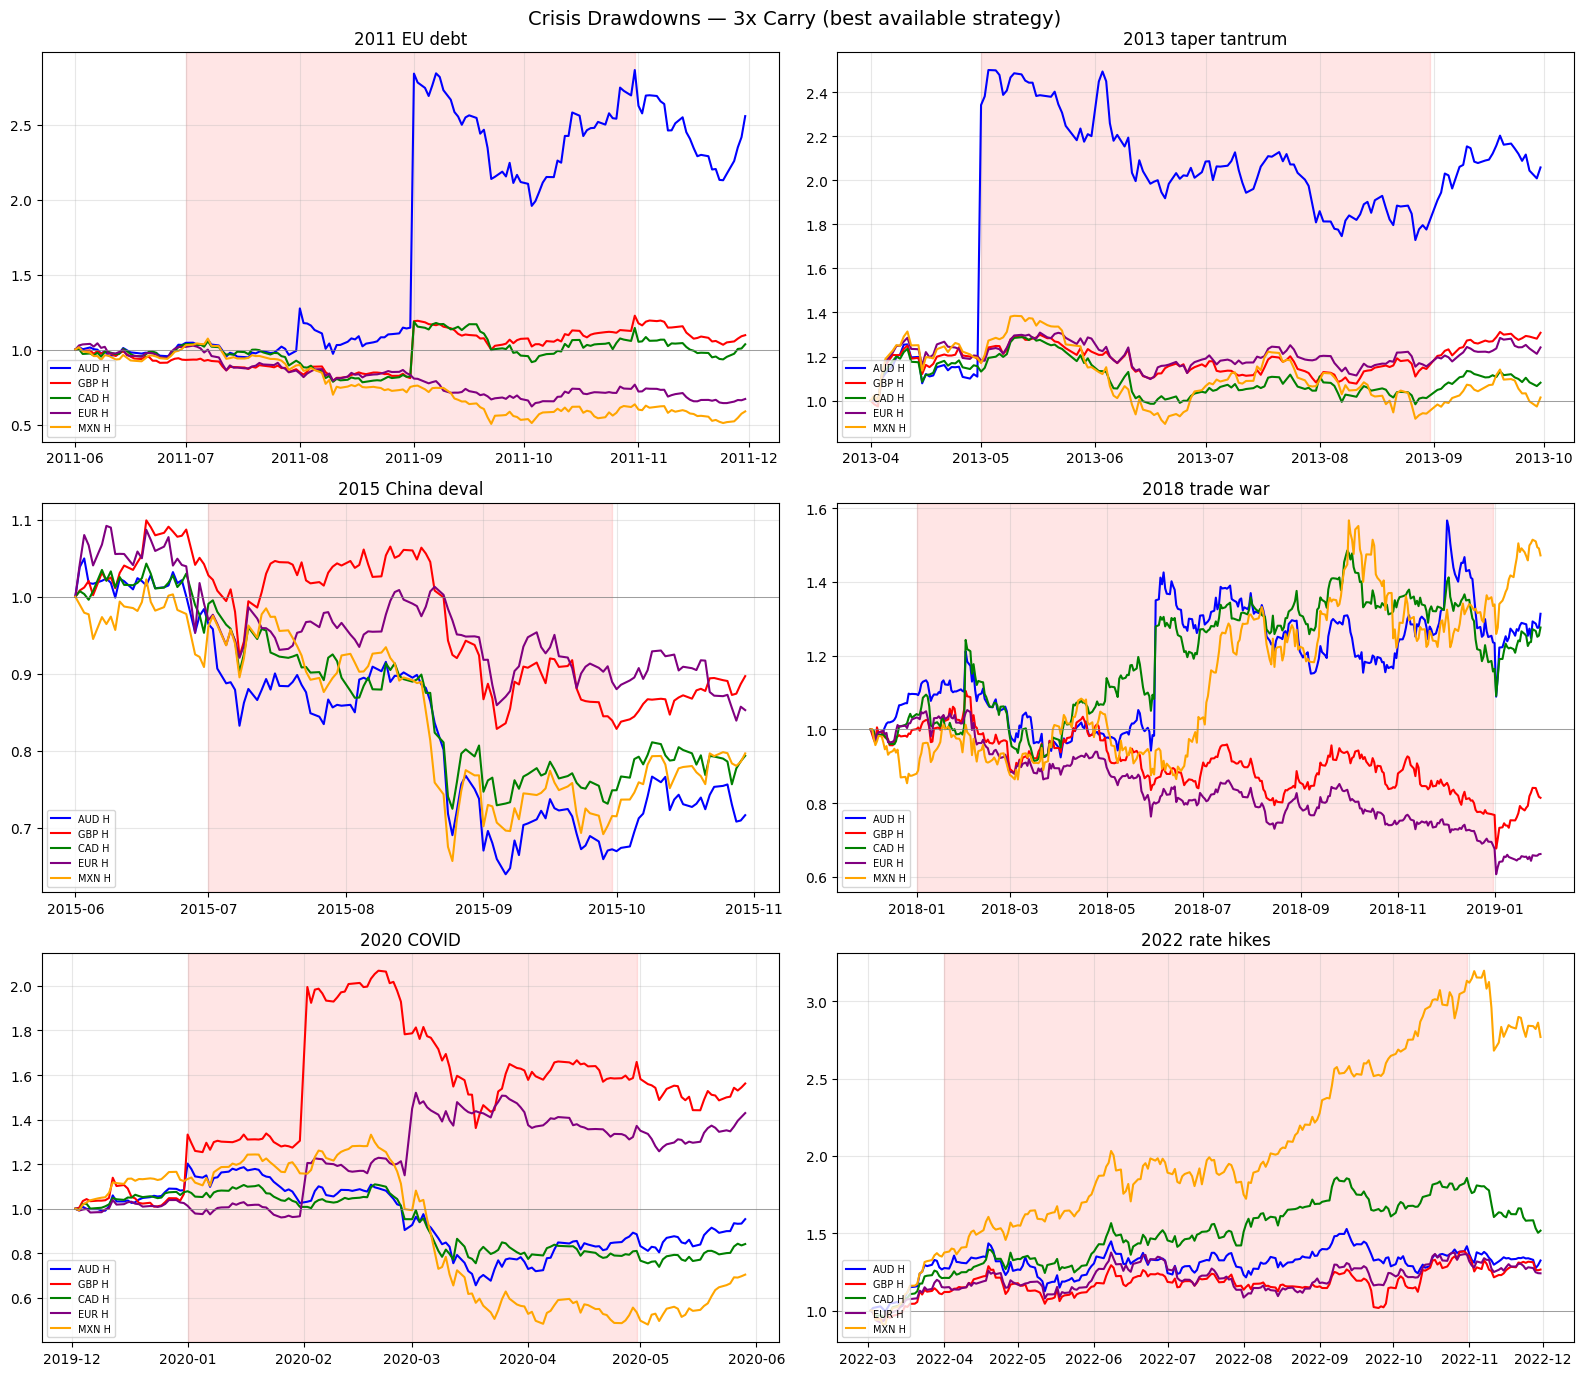

Saved to research/multi_carry_crises.png


In [14]:
# Drawdown chart during crises for 3x hedged strategies
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes_flat = axes.flatten()

for i, (name, start, end) in enumerate(crises):
    ax = axes_flat[i]
    # Extend window slightly for context
    ext_start = str(pd.Timestamp(start) - pd.Timedelta(days=30))[:10]
    ext_end = str(pd.Timestamp(end) + pd.Timedelta(days=30))[:10]
    
    for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'MXN']:
        # Show hedged if available, else unhedged
        key = (ccy, 3, True) if (ccy, 3, True) in all_results else (ccy, 3, False)
        cap = all_results[key]['capital']
        mask = (cap.index >= ext_start) & (cap.index <= ext_end)
        if mask.sum() < 2:
            continue
        subset = cap[mask]
        # Normalize to 1 at start
        norm = subset / subset.iloc[0]
        hedged = key[2]
        ls = '-' if hedged else '--'
        ax.plot(norm.index, norm, color=colors[ccy], linestyle=ls,
                label=f'{ccy}{" H" if hedged else ""}')
    
    ax.axhline(1, color='gray', linewidth=0.5)
    ax.axvspan(start, end, alpha=0.1, color='red')
    ax.set_title(name)
    ax.legend(fontsize=7, loc='lower left')
    ax.grid(True, alpha=0.3)

plt.suptitle('Crisis Drawdowns — 3x Carry (best available strategy)', fontsize=14)
plt.tight_layout()
plt.savefig('../research/multi_carry_crises.png', dpi=100, bbox_inches='tight')
plt.show()
print('Saved to research/multi_carry_crises.png')

## 9. Equal-Weight Multi-Carry Portfolio

Combine all carry pairs into a single diversified portfolio. Monthly rebalance to equal weight.

In [15]:
def build_equal_weight_portfolio(results_dict, pairs, leverage, hedged, rebal='ME'):
    """Build equal-weight portfolio from multiple carry pair backtests.
    
    Uses daily returns, rebalanced monthly.
    """
    # Collect daily returns for each pair
    daily_rets = {}
    for ccy in pairs:
        key = (ccy, leverage, hedged)
        if key not in results_dict:
            # Try unhedged if hedged not available
            key = (ccy, leverage, False)
        if key not in results_dict:
            continue
        cap = results_dict[key]['capital']
        cap = cap[cap > 0]
        daily_rets[ccy] = cap.pct_change().fillna(0)
    
    if not daily_rets:
        return None
    
    # Align to common dates
    ret_df = pd.DataFrame(daily_rets)
    ret_df = ret_df.dropna()
    
    # Equal weight: simple average of daily returns
    n_active = ret_df.notna().sum(axis=1)
    port_ret = ret_df.mean(axis=1)
    
    # Build capital series
    capital = (1 + port_ret).cumprod() * 100
    return capital


# Build portfolios
# Core pairs (full option data): AUD, GBP, CAD, EUR
core_pairs = ['AUD', 'GBP', 'CAD', 'EUR']
all_pairs = ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']

port_results = {}
for lev in [1, 3]:
    for hedged in [False, True]:
        for pairs_list, label in [(core_pairs, 'core'), (all_pairs, 'all')]:
            cap = build_equal_weight_portfolio(all_results, pairs_list, lev, hedged)
            if cap is not None:
                tag = f'{label} {lev}x {"hedged" if hedged else "unhedged"}'
                port_results[tag] = cap

# Print stats
print('=' * 120)
print('EQUAL-WEIGHT CARRY PORTFOLIO')
print('=' * 120)
print(f'{"Portfolio":>30} {"CAGR":>8} {"Vol":>6} {"Sharpe":>7} {"Sortino":>8} '
      f'{"MaxDD":>7} {"Skew":>6} {"Kurt":>6} {"Total":>7}')
print('-' * 120)

for tag in sorted(port_results.keys()):
    s = compute_stats(port_results[tag])
    if s:
        print(f'{tag:>30} {s["ann_ret"]*100:>7.2f}% {s["ann_vol"]*100:>5.1f}% '
              f'{s["sharpe"]:>7.3f} {s["sortino"]:>8.3f} '
              f'{s["max_dd"]*100:>6.1f}% {s["skew"]:>6.2f} {s["kurt"]:>6.1f} '
              f'{s["total"]:>6.1f}x')

EQUAL-WEIGHT CARRY PORTFOLIO
                     Portfolio     CAGR    Vol  Sharpe  Sortino   MaxDD   Skew   Kurt   Total
------------------------------------------------------------------------------------------------------------------------
                 all 1x hedged   10.37%  11.1%   0.932    1.586  -24.2%   9.48  314.2    4.7x
               all 1x unhedged    6.65%   8.8%   0.755    1.023  -25.9%  -0.28    4.9    2.8x
                 all 3x hedged   29.12%  33.4%   0.872    1.484  -59.3%   9.48  314.2   55.7x
               all 3x unhedged   17.86%  26.4%   0.676    0.916  -62.2%  -0.28    4.9   13.3x
                core 1x hedged    9.27%  11.2%   0.828    1.398  -23.3%   6.26  148.5    4.0x
              core 1x unhedged    5.22%   8.9%   0.585    0.795  -26.0%  -0.31    5.2    2.2x
                core 3x hedged   25.05%  33.6%   0.745    1.259  -58.3%   6.26  148.5   33.7x
              core 3x unhedged   13.10%  26.7%   0.490    0.665  -64.5%  -0.31    5.2    6.9x


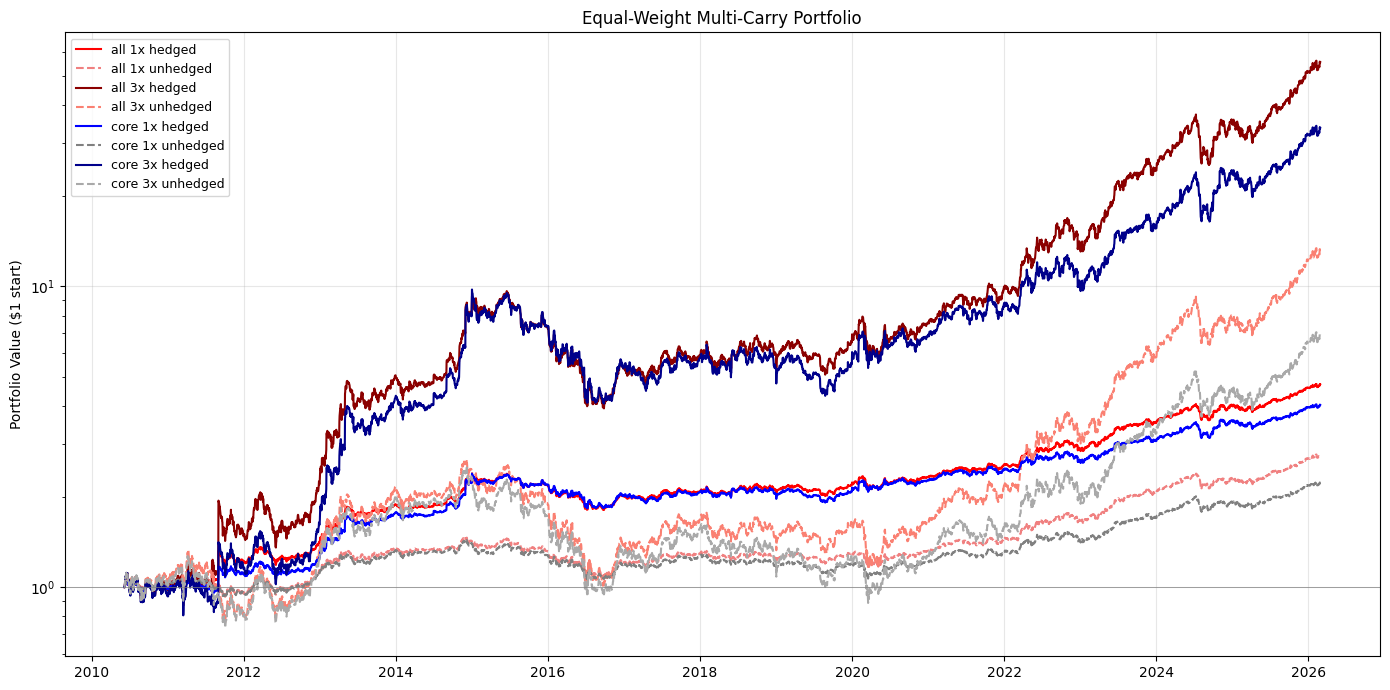

In [16]:
# Plot portfolio equity curves
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

port_colors = {
    'core 1x unhedged': ('gray', '--'),
    'core 1x hedged': ('blue', '-'),
    'core 3x unhedged': ('darkgray', '--'),
    'core 3x hedged': ('darkblue', '-'),
    'all 1x unhedged': ('lightcoral', '--'),
    'all 1x hedged': ('red', '-'),
    'all 3x unhedged': ('salmon', '--'),
    'all 3x hedged': ('darkred', '-'),
}

for tag in sorted(port_results.keys()):
    cap = port_results[tag] / 100  # normalize to $1
    color, ls = port_colors.get(tag, ('black', '-'))
    ax.plot(cap.index, cap, color=color, linestyle=ls, label=tag, linewidth=1.5)

ax.set_title('Equal-Weight Multi-Carry Portfolio')
ax.set_ylabel('Portfolio Value ($1 start)')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(1, color='gray', linewidth=0.5)
ax.set_yscale('log')

plt.tight_layout()
plt.show()

## 10. Correlation Structure

How correlated are the carry pairs? Low correlation means diversification benefit.

In [17]:
# Cross-rate return correlations
ret_matrix = pd.DataFrame()
for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    ret_matrix[f'{ccy}/JPY'] = cross_rates[ccy]['cross_ret']

corr = ret_matrix.corr()

print('CROSS-RATE RETURN CORRELATIONS (daily)')
print('=' * 70)
# Print as formatted table
header = f'{"":>10}'
for c in corr.columns:
    header += f' {c:>9}'
print(header)
for idx in corr.index:
    row = f'{idx:>10}'
    for c in corr.columns:
        val = corr.loc[idx, c]
        row += f' {val:>9.3f}'
    print(row)

print(f'\nAverage pairwise correlation: {corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack().mean():.3f}')

CROSS-RATE RETURN CORRELATIONS (daily)
             AUD/JPY   GBP/JPY   CAD/JPY   EUR/JPY   CHF/JPY   MXN/JPY
   AUD/JPY     1.000     0.686     0.785     0.683     0.475     0.690
   GBP/JPY     0.686     1.000     0.709     0.747     0.525     0.607
   CAD/JPY     0.785     0.709     1.000     0.706     0.505     0.723
   EUR/JPY     0.683     0.747     0.706     1.000     0.662     0.596
   CHF/JPY     0.475     0.525     0.505     0.662     1.000     0.391
   MXN/JPY     0.690     0.607     0.723     0.596     0.391     1.000

Average pairwise correlation: 0.633


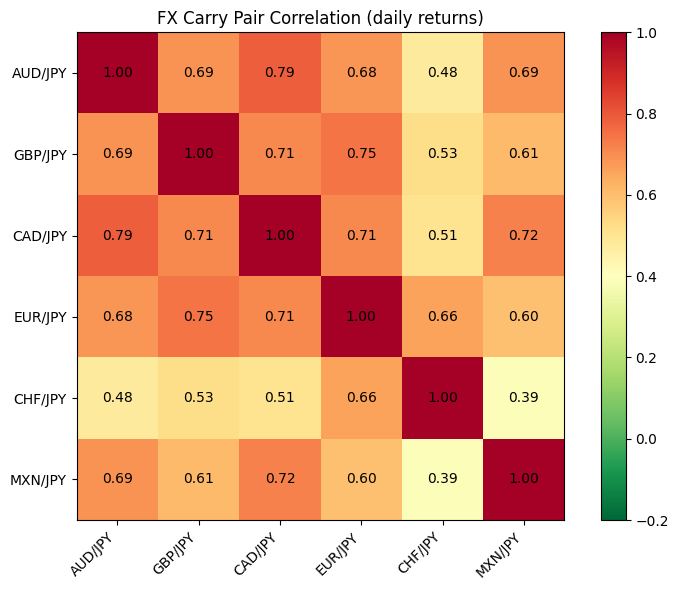

In [18]:
# Heatmap
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdYlGn_r', vmin=-0.2, vmax=1.0)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.index)

for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=10)

plt.colorbar(im, ax=ax)
ax.set_title('FX Carry Pair Correlation (daily returns)')
plt.tight_layout()
plt.show()

## 11. Put Economics — Hedge Cost vs Payoff

For each pair, decompose the P&L into carry income, spot return, and option P&L.

In [19]:
print('=' * 100)
print('P&L DECOMPOSITION — 3x LEVERAGE')
print('=' * 100)

for ccy in ['AUD', 'GBP', 'CAD', 'EUR', 'CHF', 'MXN']:
    for hedged in [False, True]:
        key = (ccy, 3, hedged)
        if key not in all_results:
            continue
        r = all_results[key]
        years = (r.index[-1] - r.index[0]).days / 365.25
        carry = r['daily_carry'].sum()
        spot = r['daily_spot'].sum()
        puts = r['put_pnl'].sum()
        
        htype = 'hedged' if hedged else 'unhedged'
        print(f'\n--- {ccy}/JPY 3x {htype} ---')
        print(f'  Carry income:  ${carry:>8.1f} ({carry/years:>6.1f}/yr)')
        print(f'  Spot P&L:      ${spot:>8.1f} ({spot/years:>6.1f}/yr)')
        if puts != 0:
            print(f'  Put P&L:       ${puts:>8.1f} ({puts/years:>6.1f}/yr)')
        print(f'  Final capital: ${r["capital"].iloc[-1]:>8.1f} (started $100)')

P&L DECOMPOSITION — 3x LEVERAGE

--- AUD/JPY 3x unhedged ---
  Carry income:  $   337.9 (  21.5/yr)
  Spot P&L:      $   676.0 (  43.0/yr)
  Final capital: $  1113.9 (started $100)

--- AUD/JPY 3x hedged ---
  Carry income:  $  3555.7 ( 226.1/yr)
  Spot P&L:      $  7487.9 ( 476.1/yr)
  Put P&L:       $  1197.0 (  76.1/yr)
  Final capital: $ 12340.6 (started $100)

--- GBP/JPY 3x unhedged ---
  Carry income:  $   136.6 (   8.7/yr)
  Spot P&L:      $   333.5 (  21.2/yr)
  Final capital: $   570.1 (started $100)

--- GBP/JPY 3x hedged ---
  Carry income:  $   450.4 (  28.6/yr)
  Spot P&L:      $  1105.7 (  70.3/yr)
  Put P&L:       $   316.1 (  20.1/yr)
  Final capital: $  1972.2 (started $100)

--- CAD/JPY 3x unhedged ---
  Carry income:  $   118.3 (   7.5/yr)
  Spot P&L:      $   182.4 (  11.6/yr)
  Final capital: $   400.7 (started $100)

--- CAD/JPY 3x hedged ---
  Carry income:  $   360.2 (  22.9/yr)
  Spot P&L:      $   530.9 (  33.8/yr)
  Put P&L:       $   230.3 (  14.6/yr)
  Fin

## 12. Conclusions

In [20]:
# Final summary comparison
print("""
MULTI-ASSET CARRY + TAIL HEDGE — KEY FINDINGS
==============================================

1. CARRY SPECTRUM:
   - MXN/JPY: highest carry (4-11%) but highest vol and crash risk
   - AUD/JPY, NZD/JPY: classic commodity carry (1-4.5%)
   - GBP/JPY: G10 carry (0.5-5%), lower vol than EM
   - CAD/JPY: commodity-linked G10 (0.5-5%)
   - EUR/JPY: core European carry, collapsed 2015-2021 (0% ECB rate)
   - CHF/JPY: negative carry 2015-2022 (SNB negative rates)

2. HEDGING VALUE:
   - Puts on AUD, GBP, CAD are most effective (deep option markets)
   - EUR puts available and useful during rate divergence periods
   - CHF/MXN option markets too thin for systematic hedging
   - Hedge improves Sharpe and Sortino for pairs with sufficient option data

3. DIVERSIFICATION:
   - Carry pairs are correlated (all short JPY) but not perfectly
   - EUR/JPY and CHF/JPY have different dynamics from commodity FX
   - MXN/JPY adds EM exposure with higher carry but fatter tails
   - Equal-weight portfolio reduces max DD relative to any single pair

4. CRISIS BEHAVIOR:
   - All carry pairs crash together during global risk-off (2008, 2020)
   - Some crises are pair-specific (2015 SNB floor removal, 2022 GBP mini-budget)
   - Hedging helps most in gradual drawdowns, less in flash crashes
   - Diversification across pairs is as important as hedging

5. PRACTICAL TAKEAWAY:
   - Core portfolio: equal-weight AUD/GBP/CAD/EUR carry vs JPY
   - Hedge with 0.5% monthly put budget on each pair
   - Add MXN for yield enhancement if you can tolerate EM risk
   - 1-3x leverage depending on risk tolerance
""")


MULTI-ASSET CARRY + TAIL HEDGE — KEY FINDINGS

1. CARRY SPECTRUM:
   - MXN/JPY: highest carry (4-11%) but highest vol and crash risk
   - AUD/JPY, NZD/JPY: classic commodity carry (1-4.5%)
   - GBP/JPY: G10 carry (0.5-5%), lower vol than EM
   - CAD/JPY: commodity-linked G10 (0.5-5%)
   - EUR/JPY: core European carry, collapsed 2015-2021 (0% ECB rate)
   - CHF/JPY: negative carry 2015-2022 (SNB negative rates)

2. HEDGING VALUE:
   - Puts on AUD, GBP, CAD are most effective (deep option markets)
   - EUR puts available and useful during rate divergence periods
   - CHF/MXN option markets too thin for systematic hedging
   - Hedge improves Sharpe and Sortino for pairs with sufficient option data

3. DIVERSIFICATION:
   - Carry pairs are correlated (all short JPY) but not perfectly
   - EUR/JPY and CHF/JPY have different dynamics from commodity FX
   - MXN/JPY adds EM exposure with higher carry but fatter tails
   - Equal-weight portfolio reduces max DD relative to any single pair

4. C